In [1]:
import numpy
import matplotlib
import sklearn
import tensorflow

print("All libraries are installed")

All libraries are installed


In [2]:
import pickle
import numpy as np

with open("RML2016.10a_dict.dat", "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(type(data))

<class 'dict'>


In [3]:
print(len(data))
print(list(data.keys())[:5])

220
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]


In [4]:
sample_key = list(data.keys())[0]

signals = data[sample_key]

print(signals.shape)

(1000, 2, 128)


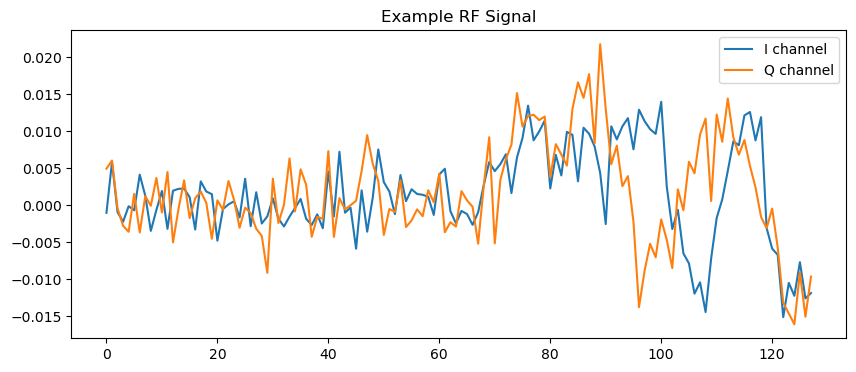

In [5]:
import matplotlib.pyplot as plt

signal = signals[0]

I = signal[0]
Q = signal[1]

plt.figure(figsize=(10,4))
plt.plot(I, label="I channel")
plt.plot(Q, label="Q channel")

plt.legend()
plt.title("Example RF Signal")
plt.show()

In [6]:
X = []
y = []

for mod_snr in data.keys():
    
    mod, snr = mod_snr
    signals = data[mod_snr]

    for signal in signals:
        X.append(signal)
        y.append(mod)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(220000, 2, 128)
(220000,)


In [7]:
X.shape
y.shape

(220000,)

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(y_encoded[:10])

[9 9 9 9 9 9 9 9 9 9]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(176000, 2, 128)
(44000, 2, 128)


In [10]:
X_train.shape
X_test.shape

(44000, 2, 128)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(176000, 2, 128)
(44000, 2, 128)
(176000,)
(44000,)


In [12]:
X_train = X_train.reshape(-1, 2, 128, 1)
X_test = X_test.reshape(-1, 2, 128, 1)

print(X_train.shape)

(176000, 2, 128, 1)


In [13]:
snrs = sorted(list(set([snr for (mod, snr) in data.keys()])))
print(snrs)

[-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [14]:
X = []
y = []

for mod_snr in data.keys():
    
    mod, snr = mod_snr
    
    if snr < 0:
        continue
        
    signals = data[mod_snr]

    for signal in signals:
        X.append(signal)
        y.append(mod)

X = np.array(X)
y = np.array(y)

In [15]:
X = X.reshape(X.shape[0], 2, 128, 1)

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42

)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D

num_classes = len(set(y_encoded))

model = Sequential()

model.add(Conv2D(128, (1,3), activation='relu', input_shape=(2,128,1)))
model.add(MaxPooling2D((1,2)))

model.add(Conv2D(128, (1,3), activation='relu'))
model.add(MaxPooling2D((1,2)))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 2, 126, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 63, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 61, 128)     │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 30, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,932,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,107 (15.21 MB)

 Trainable params: 3,988,107 (15.21 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test, y_test)
)

Epoch 1/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.4311 - loss: 1.4495 - val_accuracy: 0.5976 - val_loss: 0.9726
Epoch 2/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.6253 - loss: 0.8935 - val_accuracy: 0.6545 - val_loss: 0.7597
Epoch 3/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.6719 - loss: 0.7599 - val_accuracy: 0.6871 - val_loss: 0.6918
Epoch 4/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.6962 - loss: 0.6945 - val_accuracy: 0.6790 - val_loss: 0.6870
Epoch 5/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.7103 - loss: 0.6501 - val_accuracy: 0.7156 - val_loss: 0.6268
Epoch 6/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.7247 - loss: 0.6105 - val_accuracy: 0.7225 - val_loss: 0.6080
Epoch 7/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 49s 71ms/step - accuracy: 0.7336 - loss: 0.5770 - val_accuracy: 0.7508 - val_loss: 0.5319
Epoch 8/15
688/688 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.7485 - loss: 0.5427 - 

In [23]:
X.shape

(110000, 2, 128, 1)

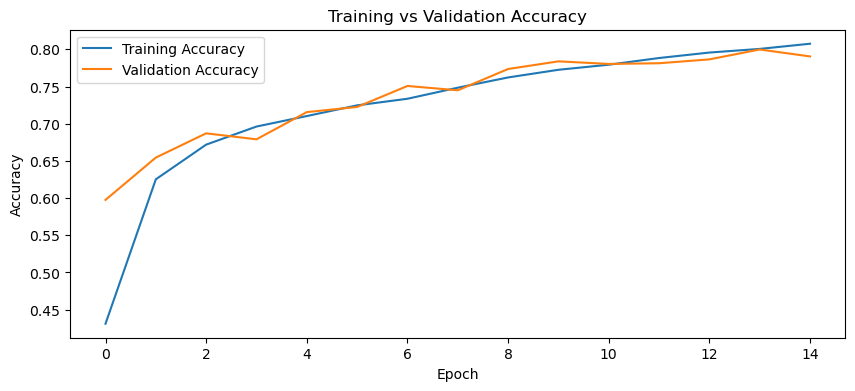

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

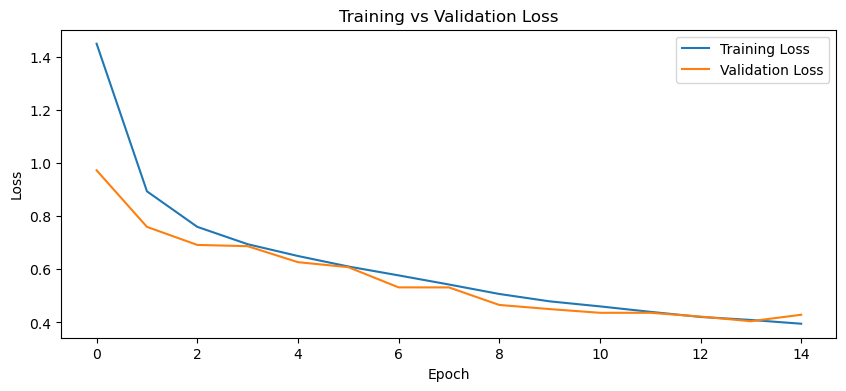

In [25]:
plt.figure(figsize=(10,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [26]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Final Test Accuracy:", accuracy)

688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7905 - loss: 0.4288
Final Test Accuracy: 0.7904999852180481


In [27]:
predictions = model.predict(X_test)
predicted_labels = predictions.argmax(axis=1)

688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


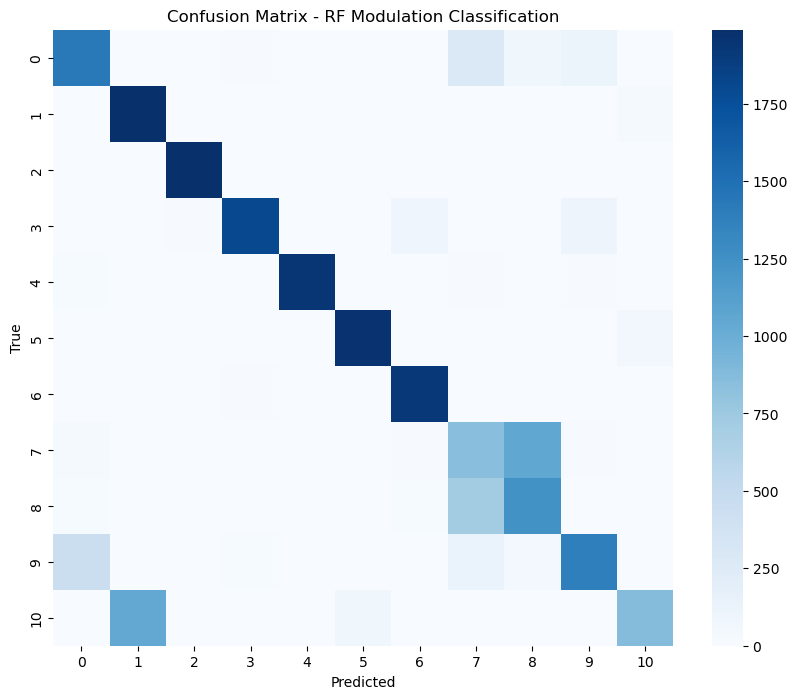

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - RF Modulation Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

In [29]:
model.save("RF_modulation_classifier.h5")

In [30]:
sample = X_test[0:1]

prediction = model.predict(sample)
predicted_class = prediction.argmax(axis=1)

print("Predicted class:", predicted_class)
print("Predicted modulation:", encoder.inverse_transform(predicted_class))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted class: [2]
Predicted modulation: ['AM-SSB']


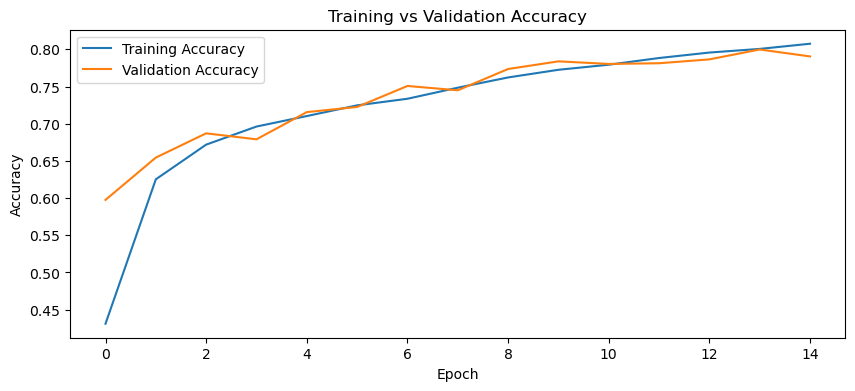

In [31]:
plt.figure(figsize=(10,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig("training_accuracy.png")

plt.show()

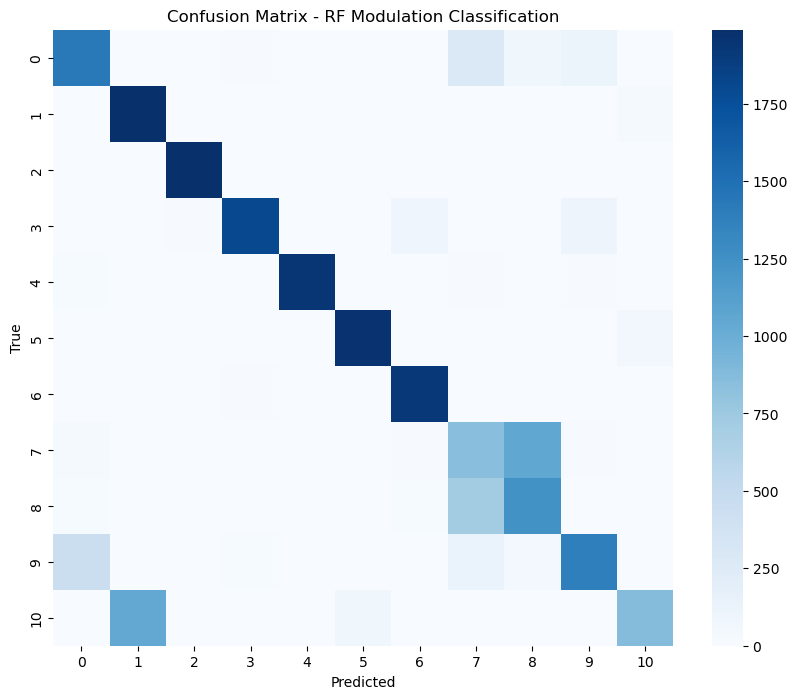

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix - RF Modulation Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.savefig("confusion_matrix.png")

plt.show()